In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_squared_log_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.callbacks import EarlyStopping

# **1. Dataset**

In [87]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [88]:
ds = pd.read_csv('/content/drive/MyDrive/colab-notebooks/predicting-house-prices/dataset/housing.csv')
ds

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [89]:
ds.shape  # 2D Dataframe: (rows, columns)

(20640, 10)

In [90]:
ds.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [91]:
ds[["total_rooms", "total_bedrooms", "median_house_value"]] # 2D Dataframe: (rows, columns)

,total_rooms,total_bedrooms,median_house_value
0,880.0,129.0,452600.0
1,7099.0,1106.0,358500.0
2,1467.0,190.0,352100.0
3,1274.0,235.0,341300.0
4,1627.0,280.0,342200.0
...,...,...,...
20635,1665.0,374.0,78100.0
20636,697.0,150.0,77100.0
20637,2254.0,485.0,92300.0
20638,1860.0,409.0,84700.0


In [92]:
ds["median_house_value"] # 1D series: (rows,)

,median_house_value
0,452600.0
1,358500.0
2,352100.0
3,341300.0
4,342200.0
...,...
20635,78100.0
20636,77100.0
20637,92300.0
20638,84700.0


In [93]:
ds["median_house_value"][0]

np.float64(452600.0)

In [94]:
ds.isnull().sum()   # check null

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [95]:
ds.info() # check kiểu

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [96]:
for col in ds.columns:
    print(ds[col].map(type).value_counts(), '\n')
    print("=====================================")

longitude
<class 'float'>    20640
Name: count, dtype: int64 

latitude
<class 'float'>    20640
Name: count, dtype: int64 

housing_median_age
<class 'float'>    20640
Name: count, dtype: int64 

total_rooms
<class 'float'>    20640
Name: count, dtype: int64 

total_bedrooms
<class 'float'>    20640
Name: count, dtype: int64 

population
<class 'float'>    20640
Name: count, dtype: int64 

households
<class 'float'>    20640
Name: count, dtype: int64 

median_income
<class 'float'>    20640
Name: count, dtype: int64 

median_house_value
<class 'float'>    20640
Name: count, dtype: int64 

ocean_proximity
<class 'str'>    20640
Name: count, dtype: int64 



# **#. String-columns**

In [97]:
for col in ['ocean_proximity']:
  ds[col] = ds[col].apply(
    lambda val: str(val).strip().lower() if pd.notnull(val) and (str(val).strip().lower() not in ["null", "nan", "n/a", "none"]) else ""
  )

  # mode
  mode_vals = ds.loc[ds[col] != "", col].mode()
  if not mode_vals.empty:
      ds[col] = ds[col].replace("", mode_vals[0])

In [98]:
ds['ocean_proximity'].value_counts() # xác định encoder

,count
ocean_proximity,
<1h ocean,9136
inland,6551
near ocean,2658
near bay,2290
island,5


In [99]:
ocp_encoder = OneHotEncoder(sparse_output=False) # encode nhị phân

ocp_encoded = ocp_encoder.fit_transform(ds[['ocean_proximity']]) # fit và transform

type(ocp_encoded)

numpy.ndarray

In [100]:
df_ocp_encoded = pd.DataFrame(
    ocp_encoded,
    columns = ocp_encoder.get_feature_names_out(
        ['ocean_proximity']
    ),
    index = ds.index
)

ds = pd.concat([ds.drop('ocean_proximity', axis=1), df_ocp_encoded], axis=1) # nối dataframe

ds.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1h ocean,ocean_proximity_inland,ocean_proximity_island,ocean_proximity_near bay,ocean_proximity_near ocean
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0.0,0.0,0.0,1.0,0.0
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,0.0,0.0,0.0,1.0,0.0
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,0.0,0.0,0.0,1.0,0.0
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,0.0,0.0,0.0,1.0,0.0
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,0.0,0.0,0.0,1.0,0.0
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,0.0,0.0,0.0,1.0,0.0


# **#. Numeric-columns**

In [ ]:
for col_name in ["longitude", "latitude", "housing_median_age", "total_rooms", "total_bedrooms", "population", "households", "median_income", "median_house_value"]:
  ds[col_name] = pd.to_numeric(ds[col_name], errors='coerce') # invalid thành NaN
  ds[col_name] = ds[col_name].fillna(ds[col_name].median()) # trung vị

In [102]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   20640 non-null  float64
 1   latitude                    20640 non-null  float64
 2   housing_median_age          20640 non-null  float64
 3   total_rooms                 20640 non-null  float64
 4   total_bedrooms              20640 non-null  float64
 5   population                  20640 non-null  float64
 6   households                  20640 non-null  float64
 7   median_income               20640 non-null  float64
 8   median_house_value          20640 non-null  float64
 9   ocean_proximity_<1h ocean   20640 non-null  float64
 10  ocean_proximity_inland      20640 non-null  float64
 11  ocean_proximity_island      20640 non-null  float64
 12  ocean_proximity_near bay    20640 non-null  float64
 13  ocean_proximity_near ocean  206

# **#. Split**

In [103]:
Y = ds[["median_house_value"]]
Y.head()

,median_house_value
0,452600.0
1,358500.0
2,352100.0
3,341300.0
4,342200.0


In [104]:
Y.shape

(20640, 1)

In [105]:
X = ds.drop(['median_house_value'], axis=1)
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1h ocean,ocean_proximity_inland,ocean_proximity_island,ocean_proximity_near bay,ocean_proximity_near ocean
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,0.0,0.0,0.0,1.0,0.0


In [106]:
X.shape

(20640, 13)

In [107]:
X_train, X_remain, Y_train, Y_remain = train_test_split(X, Y, test_size=0.15, shuffle=True, random_state=123)  # 15% remain

test_length = math.floor(0.01*len(X)) # 1% của X

remain_length = len(X_remain)

test_ratio_in_remain = test_length/remain_length

X_val, X_test, Y_val, Y_test = train_test_split(X_remain, Y_remain, test_size=test_ratio_in_remain, shuffle=True, random_state=123)

X_train = X_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

Y_train = Y_train.reset_index(drop=True)
Y_val = Y_val.reset_index(drop=True)
Y_test = Y_test.reset_index(drop=True)

# **#. Scale**

-chia tỉ lệ về [0, 1]

-chỉ scale sau khi đã split

In [108]:
ocp_names = ["ocean_proximity_<1h ocean", "ocean_proximity_inland", "ocean_proximity_island", "ocean_proximity_near bay", "ocean_proximity_near ocean"]

ocp_cols_train = X_train[ocp_names]
ocp_cols_val = X_val[ocp_names]
ocp_cols_test = X_test[ocp_names]

X_scaler = StandardScaler()
Y_scaler = StandardScaler()

X_train = pd.DataFrame(
    X_scaler.fit_transform(X_train.drop(columns=ocp_names)), # fit và transform
    columns=X_train.drop(columns=ocp_names).columns,
    index=X_train.index
)

X_val = pd.DataFrame(
    X_scaler.transform(X_val.drop(columns=ocp_names)), # transform
    columns=X_val.drop(columns=ocp_names).columns,
    index=X_val.index
)

X_test = pd.DataFrame(
    X_scaler.transform(X_test.drop(columns=ocp_names)), # transform
    columns=X_test.drop(columns=ocp_names).columns,
    index=X_test.index
)

X_train = pd.concat([X_train, ocp_cols_train], axis=1) # DataFrame (-1, 13)
X_val = pd.concat([X_val, ocp_cols_val], axis=1)
X_test = pd.concat([X_test, ocp_cols_test], axis=1)

Y_train = pd.DataFrame(
    Y_scaler.fit_transform(Y_train),
    columns=Y_train.columns,
    index=Y_train.index
)

Y_val = pd.DataFrame(
    Y_scaler.transform(Y_val),
    columns=Y_val.columns,
    index=Y_val.index
)

Y_test = pd.DataFrame(
    Y_scaler.transform(Y_test),
    columns=Y_test.columns,
    index=Y_test.index
)

X_train

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1h ocean,ocean_proximity_inland,ocean_proximity_island,ocean_proximity_near bay,ocean_proximity_near ocean
0,0.874011,-0.890631,-0.366042,-0.820961,-0.827032,-0.846231,-0.810054,0.443014,1.0,0.0,0.0,0.0,0.0
1,0.628983,-0.843790,1.301640,0.132450,0.515511,0.184298,0.394302,-0.489597,1.0,0.0,0.0,0.0,0.0
2,-1.341244,1.043919,1.857534,-0.425689,-0.522880,-0.634405,-0.536337,0.623792,0.0,0.0,0.0,1.0,0.0
3,-1.406251,2.369531,-0.604283,-0.395952,-0.399319,-0.494975,-0.382534,-1.120683,0.0,1.0,0.0,0.0,0.0
4,0.834007,-0.820369,-0.048389,0.025854,-0.456347,-0.430623,-0.377320,2.714142,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17539,0.733995,-0.806317,0.586919,-0.875403,-0.244867,-0.839081,-0.966464,-0.119277,1.0,0.0,0.0,0.0,0.0
17540,1.164045,-1.059260,-1.160177,0.936719,0.605806,0.900216,0.725369,0.356004,1.0,0.0,0.0,0.0,0.0
17541,-1.096216,0.795660,-1.874898,0.692419,0.429969,0.899323,0.511609,0.932287,1.0,0.0,0.0,0.0,0.0
17542,-1.436255,1.006446,1.222226,-0.500718,-0.484861,-0.775622,-0.455525,0.005378,0.0,0.0,0.0,1.0,0.0


In [109]:
Y_train

,median_house_value
0,0.160778
1,0.577714
2,2.169892
3,-1.259414
4,1.467180
...,...
17539,-0.337809
17540,-0.222283
17541,0.692372
17542,1.789437


# **2. Model**

In [110]:
model = Sequential()

model.add(Input(shape=(X_train.shape[1],)))  # shape=(13,)

model.add(Dense(256))  # linear regression
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.2))

model.add(Dense(128))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.1))

model.add(Dense(64))
model.add(BatchNormalization())
model.add(Activation('relu'))

# output-layer, 1 neuron, linear regression
model.add(Dense(1))

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 256)            │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,593 (182.00 KB)

 Trainable params: 45,697 (178.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [111]:
model.compile(optimizer='adam', loss=MeanSquaredError(), metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', mode='min', patience=20, restore_best_weights=True)

history = model.fit(X_train, Y_train,
                    validation_data=(X_val, Y_val),
                    epochs=500,
                    batch_size=250,
                    callbacks=[early_stop], verbose=1)

Epoch 1/500
71/71 ━━━━━━━━━━━━━━━━━━━━ 18s 72ms/step - loss: 0.5156 - mae: 0.5258 - val_loss: 0.5926 - val_mae: 0.5822
Epoch 2/500
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3416 - mae: 0.4242 - val_loss: 0.4279 - val_mae: 0.4919
Epoch 3/500
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3066 - mae: 0.3973 - val_loss: 0.3298 - val_mae: 0.4160
Epoch 4/500
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2926 - mae: 0.3863 - val_loss: 0.3050 - val_mae: 0.3898
Epoch 5/500
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2835 - mae: 0.3782 - val_loss: 0.2520 - val_mae: 0.3424
Epoch 6/500
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2754 - mae: 0.3716 - val_loss: 0.2341 - val_mae: 0.3306
Epoch 7/500
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2683 - mae: 0.3667 - val_loss: 0.2246 - val_mae: 0.3245
Epoch 8/500
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2655 - mae: 0.3633 - val_loss: 0.2314 - val_mae: 0.3303
Epoch 9/500
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2

# **3. Save model**

In [112]:
import pickle

pickle_dir_path="/content/drive/MyDrive/colab-notebooks/predicting-house-prices/model"

model.save(f"{pickle_dir_path}/model.keras")

with open(f'{pickle_dir_path}/ocp_encoder.pkl', 'wb') as f1:
    pickle.dump(ocp_encoder, f1)

with open(f'{pickle_dir_path}/X_scaler.pkl', 'wb') as f2:
    pickle.dump(X_scaler, f2)

with open(f'{pickle_dir_path}/Y_scaler.pkl', 'wb') as f3:
    pickle.dump(Y_scaler, f3)

# **4. Đánh giá**

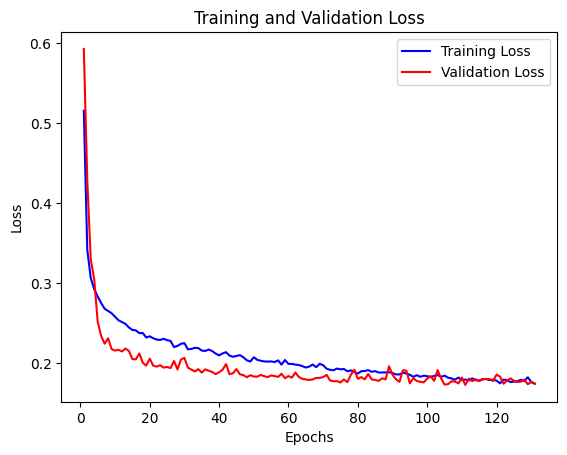

In [113]:
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

epochs = range(1, len(training_loss) + 1)

plt.plot(epochs, training_loss, 'b', label='Training Loss')
plt.plot(epochs, validation_loss, 'r', label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

549/549 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


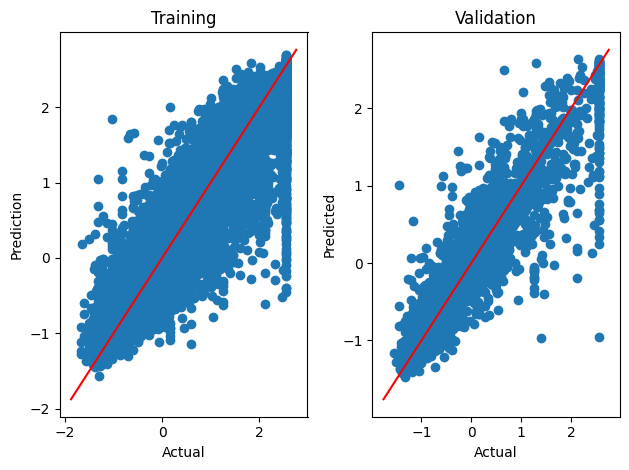

In [114]:
fig, axes = plt.subplots(1,2)

axes[0].scatter(x=Y_train, y=model.predict(X_train))
axes[0].set_xlabel('Actual', fontsize=10)
axes[0].set_ylabel('Prediction', fontsize=10)
axes[0].set_title('Training')

x = np.linspace(*axes[0].get_xlim())
axes[0].plot(x, x, color='red')

axes[1].scatter(x=Y_val, y=model.predict(X_val))
axes[1].set_xlabel('Actual', fontsize=10)
axes[1].set_ylabel('Predicted', fontsize=10)
axes[1].set_title('Validation')

x = np.linspace(*axes[1].get_xlim())
axes[1].plot(x, x, color='red')

fig.tight_layout()
plt.show()

In [ ]:
# đánh giá model trên tập test
Y_predict = model.predict(X_test)

print("MAE:", mean_absolute_error(Y_test, Y_predict))
print("MSE:", mean_squared_error(Y_test, Y_predict))
print("MSLE:", mean_squared_log_error(
    Y_scaler.inverse_transform(Y_test),  # StandardScaler() có thể âm
    Y_scaler.inverse_transform(Y_predict)
))
print("R-Square:", r2_score(Y_test, Y_predict))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
MAE: 0.26854780316352844
MSE: 0.18270087242126465
MSLE: 0.049280219226323384
R-Square: 0.819673478603363


In [116]:
print(f"Predicted median_house_value:", Y_scaler.inverse_transform(Y_predict)[:10])
print(f"Actual median_house_value:", Y_scaler.inverse_transform(Y_test)[:10])

Predicted median_house_value: [[ 73582.96]
 [195110.  ]
 [119251.44]
 [ 62530.32]
 [179869.78]
 [300211.3 ]
 [161551.97]
 [140718.58]
 [415486.28]
 [264693.88]]
Actual median_house_value: [[ 75800.]
 [142600.]
 [133300.]
 [ 82300.]
 [192400.]
 [289200.]
 [160200.]
 [135500.]
 [380400.]
 [296200.]]


In [117]:
# !pip freeze > /content/drive/MyDrive/colab-notebooks/requirements.txt